In [1]:
using Revise
using Pkg
Pkg.activate("C:/Users/jtgrasb/Documents/GitHub/sireno/dev_env")
Pkg.instantiate()

  Activating project at `C:\Users\jtgrasb\Documents\GitHub\sireno\dev_env`
Precompiling packages...
 241676.2 ms  ✓ SIRENOpt
  1 dependency successfully precompiled in 405 seconds. 727 already precompiled.


In [2]:
using PVlib

using SIRENOpt

using HTTP
using JSON
using DataFrames
using Dates
using CSV
using Plots
using Statistics
using LinearAlgebra
using TimeZones

using Optim
using FiniteDiff
using ForwardDiff

using MAT

In [3]:
# create function that support initial tilt input
function dc_power_return(latitude, longitude, altitude, 
                        initial_tilt, initial_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)
    
    panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, initial_tilt, initial_azimuth)

    total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data, sol_position, albedo, sim_time) 
    cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data)

    effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, panel_tilt, panel_azimuth, altitude)

    f_shade = get_shaded_fraction(sol_position, panel_tilt, panel_azimuth, panel, obstacle, nx=10, ny=10)
    power_norm = get_power_norm(total_irradiance, f_shade, n_cells_per_column)

    dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)
    ac_power = sandia_ac_power(pv_inverter, dc_components_shaded)
    return getfield.(dc_components_shaded, :p_mp)
end

dc_power_return (generic function with 1 method)

In [4]:
data = matread("pioneer_6dof_response_wave1.mat")
time = vec(data["time"])
WEC_response = data["WEC_response"]

dt = time[2] - time[1]
T = time[end] + dt
time3 = vcat(time, time .+ T, time .+ (2*T))
WEC_response3 = vcat(WEC_response, WEC_response, WEC_response)

39003×6 Matrix{Float64}:
 -8.83514  -26.697   0.298      0.0          -0.0           0.0
 -8.83514  -26.697   0.30334    9.70905e-10  -2.99434e-8    2.69381e-10
 -8.83514  -26.697   0.3189    -6.88928e-8   -9.36079e-8    1.0716e-9
 -8.83514  -26.697   0.343368  -1.63306e-7   -2.03642e-7    2.88071e-9
 -8.83514  -26.697   0.374012  -4.48885e-8   -4.3755e-7     6.38232e-9
 -8.83514  -26.697   0.407384   3.75152e-7   -8.28285e-7    1.05373e-8
 -8.83513  -26.697   0.440324   1.0706e-6    -1.38096e-6    1.69084e-8
 -8.83513  -26.697   0.470121   2.05582e-6   -2.1206e-6     2.5734e-8
 -8.83513  -26.697   0.494816   3.45079e-6   -3.11331e-6    3.69899e-8
 -8.83513  -26.697   0.512905   5.46931e-6   -4.46141e-6    5.21309e-8
 -8.83513  -26.697   0.523388   8.38691e-6   -6.28279e-6    6.96049e-8
 -8.83513  -26.697   0.52606    1.26132e-5   -8.74278e-6    8.72951e-8
 -8.83514  -26.697   0.521401   1.88153e-5   -1.20837e-5    1.07294e-7
  ⋮                                                         

In [5]:
# load in WEC respponse
data = matread("pioneer_6dof_response_wave1.mat")
time = vec(data["time"])
WEC_response = data["WEC_response"]

latitude = 35.95
initial_tilt = latitude
initial_azimuth = 180
initial_yaw = 0
panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, initial_tilt, initial_azimuth, initial_yaw)


([35.95, 35.95000005562879, 35.94999605273519, 35.949990643274845, 35.94999742808681, 35.95002149463071, 35.95006134076051, 35.950117790241706, 35.950197716223286, 35.95031336941291  …  35.50606341315902, 32.88191076837323, 30.413627002653378, 28.157335665477547, 26.160206992534704, 24.460946417316954, 23.091062925925492, 22.07657565519575, 21.44184902852915, 21.211254355297484], [180.0, 180.00000235026764, 180.00000733416468, 180.00001592384714, 180.00003420331822, 180.00006483549063, 180.00010813487316, 180.0001660645739, 180.0002438483768, 180.0003494864102  …  179.15599898726992, 178.2557008446796, 177.26876254777585, 176.23950538669237, 175.24062166228626, 174.37358098438875, 173.76385144834674, 173.53966021028353, 173.7933318600634, 174.55313909481978], [0.8095296256563844, 0.809529625086386, 0.8095296661018815, 0.8095297215297024, 0.8095296520093944, 0.8095294054124104, 0.8095289971301483, 0.8095284187214371, 0.809527599759794, 0.8095264147164923  …  0.8140540600226824, 0.839791

In [6]:
# location and installation details for pioneer
latitude = 35.95
longitude = -75.125
altitude = 0.0 # m
api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"
start_monthday=(1, 1)
end_monthday=(1, 1)
number_of_panels = 1
initial_azimuth = 180.0
initial_tilt = latitude
module_name = "Kyocera Solar KC40T [2008 (E)]" #"Canadian Solar CS5P-220M [ 2009]" 
inverter_name = "Enphase Energy Inc : M175-24-208-Sxx [208V]" #"ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # 175 W is well above max power needed
pv_module = read_solar_module(module_name)
pv_inverter = read_solar_inverter(inverter_name);

# installation characteristics
panel = Panel(0.526, 0.652) # panel dimensnions in meters (Kyocera Solar KC40T [2008 (E)])
# A box above the panel
obstacle = BoxObstacle(
    -0.5, 0.5,   # x-range
    -0.3, 0.3,     # y-range
    0.4, 0.5   # z-range
)
n_cells_per_column = 9

# import weather data, calculate solar position, and corresponding albedo
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)
weather_data = weather_data[12] # just use the 12th hour for this simulation
sol_position = get_solar_position(latitude, longitude, altitude, weather_data)
albedo = get_ocean_surface_albedo(weather_data, sol_position)


0.06193415557060577

In [7]:
function objective(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)

    avg_power = mean(dc_power_return(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time))
    return -avg_power
end

installation_tilt = latitude
installation_azimuth = 180.0

check_mean_power = objective(latitude, longitude, altitude, installation_tilt, installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)
println("Mean power for installation tilt: ", -check_mean_power)

mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

Mean power for installation tilt: 7.756580302086749


#2 (generic function with 1 method)

In [8]:
pathof(SIRENOpt)
Pkg.status("SIRENOpt")

Status `C:\Users\jtgrasb\Documents\GitHub\SIRENO\dev_env\Project.toml`
  [d5b4a993] SIRENOpt v0.1.0 `C:\Users\jtgrasb\Documents\GitHub\SIRENO\sirenopt.jl`


In [42]:
# function to simulate battery storage

# can I operate with just solar module and battery?

function full_system_hydrodynamics6dof_wave(; T::Type{<:Real} = Float64)
    return hydrodynamics_wave_components(
        omega = T.([0.5, 0.8, 1.1]),
        phase = T.([0.0, pi / 3, 2pi / 3]),
        spectrum = T.([1.8, 1.2, 1.1]),
        dω = T(0.2),
        start_time_s = zero(T),
        ramp_time_s = zero(T),
    )
end

function full_system_hydrodynamics6dof_model(; T::Type{<:Real} = Float64)
    mass_matrix = Diagonal(T.([55_000, 55_000, 67_000, 1.9e6, 2.2e6, 2.5e6]))

    hydrostatic = zeros(T, 6, 6)
    hydrostatic[3, 3] = T(90_000)
    hydrostatic[4, 4] = T(2.0e6)
    hydrostatic[5, 5] = T(2.2e6)

    radiation_damping = Diagonal(T.([900, 1_000, 2_500, 1.0e4, 1.2e4, 1.4e4]))

    excitation = zeros(T, 6, 1, 3, 2)
    excitation[1, 1, :, 1] .= T.([800, 1_000, 900])
    excitation[3, 1, :, 1] .= T.([4_500, 5_500, 4_000])
    excitation[5, 1, :, 1] .= T.([1.0e5, 1.2e5, 9.0e4])

    return hydrodynamics6dof_platform_model(
        mass_matrix = mass_matrix,
        hydrostatic_stiffness = hydrostatic,
        radiation_damping = radiation_damping,
        excitation_coeff = excitation,
        wave = full_system_hydrodynamics6dof_wave(T = T),
        pto_damping = Diagonal(T.([400, 400, 1_200, 6.0e4, 6.0e4, 2.0e4])),
    )
end

T = Float64
end_time = 50
dt_s = 0.1
n_steps = Int(end_time/dt_s)
times_s = [T(i * dt_s) for i in 0:(n_steps - 1)]
times_h = times_s ./ T(3600)

platform_model = full_system_hydrodynamics6dof_model(T = T)

pv_model = pvlib_solar_model(
        surface_tilt_deg = 35.1,
        surface_azimuth_deg = 180.0,
        altitude_m = 1500.0,
    )
storage_template = SIRENOpt.AgnosticStorageDynamics.StorageParams(
        energy_capacity = 1.0,
        charge_rate_max = 1.0,
        discharge_rate_max = 1.0,
        standing_loss_rate = 0.0,
    )

design = SystemDesign{T}(
        solar = SolarDesign{T}(area = T(120), efficiency = one(T), pv_model = pv_model),
        wave = WaveDesign{T}(capture_width = T(12), rated_power = T(25)),
        battery = BatteryDesign{T}(
            capacity_kwh = T(20),
            max_charge_kw = T(8),
            max_discharge_kw = T(8),
            storage_model = storage_template,
        ),
        platform = PlatformDesign{T}(base_mass = T(55_000), hydrodynamic_model = platform_model),
    )

function _full_system_demo_profile(values, n_steps::Int, ::Type{T}) where {T<:Real}
    return [T(values[mod1(i, length(values))]) for i in 1:n_steps]
end

platform_wrenches = [
        T[150 + 10i, 0, 300 + 20i, 0, 2_000 + 100i, 0] for i in 0:(n_steps - 1)
    ]

op = SystemOperation{T}(
        solar = SolarOp{T}(
            resource = TimeSeries(times_h, zeros(T, n_steps)),
            pv_weather = fill(weather_data, n_steps),
            pv_solar_position = fill(sol_position, n_steps),
        ),
        wave = WaveOp{T}(resource = TimeSeries(times_h,
            _full_system_demo_profile([1.4, 1.6, 1.5, 1.7, 1.6, 1.5, 1.4, 1.6], n_steps, T))),
        load = LoadOp{T}(demand = TimeSeries(times_h,
            _full_system_demo_profile([100], n_steps, T))),
        battery = BatteryOp{T}(soc_init = T(0.5)),
        platform = PlatformOp{T}(
            external_wrench = TimeSeries(times_h, platform_wrenches),
            wave_components = full_system_hydrodynamics6dof_wave(T = T),
        ),
    )

dt_hours = T(dt_s) / T(3600)

function full_system_hydrodynamics6dof_dispatch(_design, _op, _state, _k, dt_hours)
    T = typeof(dt_hours)
    return ControlSetpoints{T}(
        solar_curtailment = zero(T),
        battery_power_kw = -T(2.0),
    )
end


full_system_hydrodynamics6dof_dispatch (generic function with 1 method)

In [43]:
states, outputs = simulate(design, op, dt_hours; control = full_system_hydrodynamics6dof_dispatch)

final = states[end]

println("solar + battery demo")
println("  steps: $(length(outputs)), dt: $(dt_hours * 3600) s")
#println("  final heave: $(round(final.platform.position[3], digits = 5)) m")
println("  final battery SOC: $(round(final.battery_soc, digits = 4))")
#println("  diesel fuel used: $(round(total_fuel, digits = 5)) L")

solar + battery demo
  steps: 500, dt: 0.1 s
  final battery SOC: 0.5013


In [44]:
println(states[1].platform)
println(states[1].platform.position)

PlatformState6DOF{Float64}([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0; 0.0; 0.0; 0.0; 0.0; 0.0;;])
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


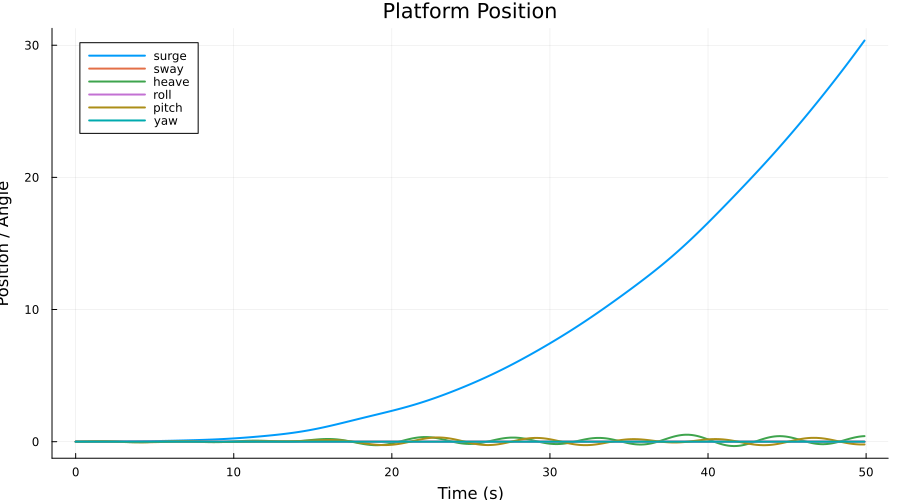

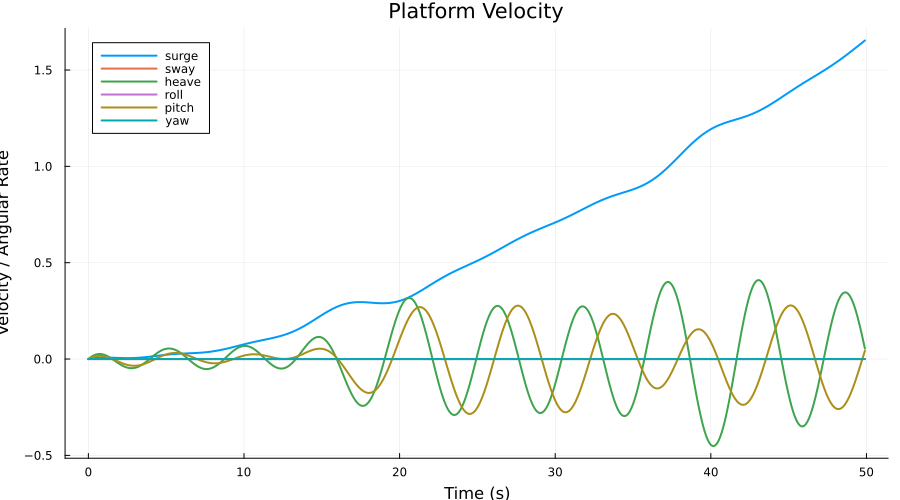

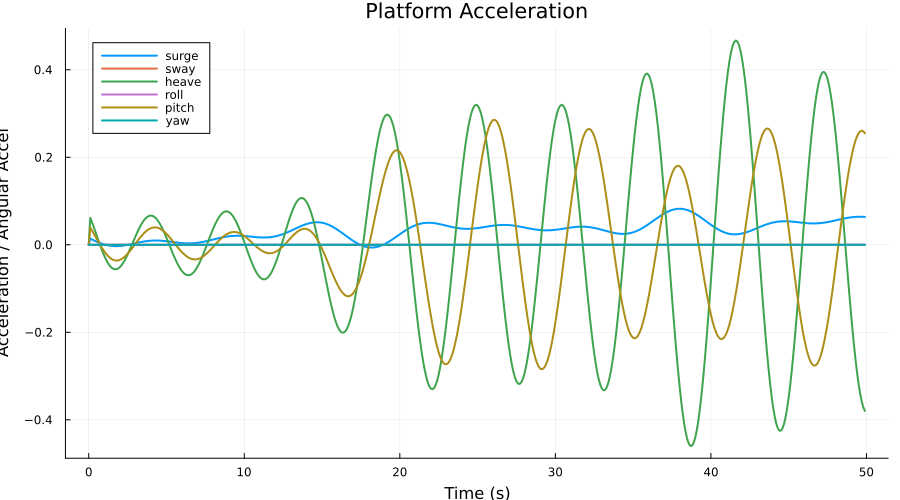

In [45]:
t   = [s.time for s in states]
t = T(3600) .* t
pos = hcat([s.platform.position for s in states]...)
vel = hcat([s.platform.velocity for s in states]...)
acc = hcat([s.platform.acceleration for s in states]...)

labels = ["surge", "sway", "heave", "roll", "pitch", "yaw"]

p1 = plot(title="Platform Position", xlabel="Time (s)", ylabel="Position / Angle", size=(900,500))
for i in 1:6
    plot!(p1, t, pos[i, :], lw=2, label=labels[i])
end
display(p1)

p2 = plot(title="Platform Velocity", xlabel="Time (s)", ylabel="Velocity / Angular Rate", size=(900,500))
for i in 1:6
    plot!(p2, t, vel[i, :], lw=2, label=labels[i])
end
display(p2)

p3 = plot(title="Platform Acceleration", xlabel="Time (s)", ylabel="Acceleration / Angular Accel", size=(900,500))
for i in 1:6
    plot!(p3, t, acc[i, :], lw=2, label=labels[i])
end
display(p3)

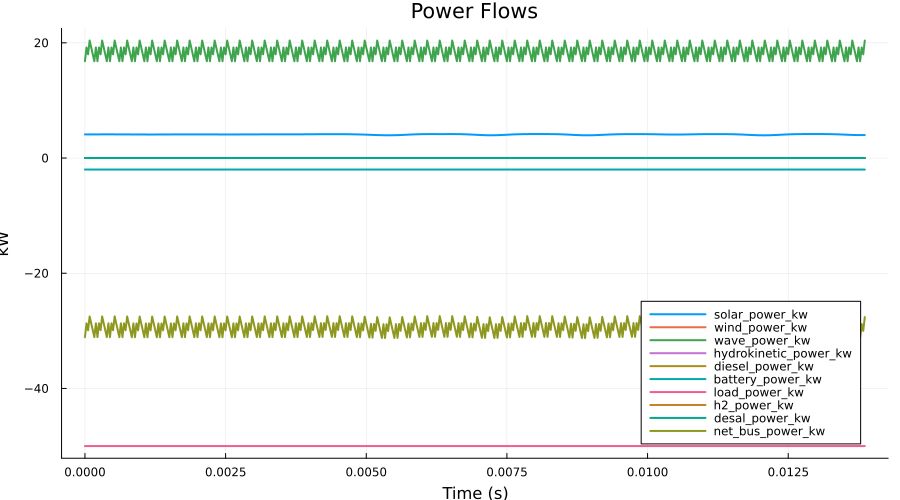

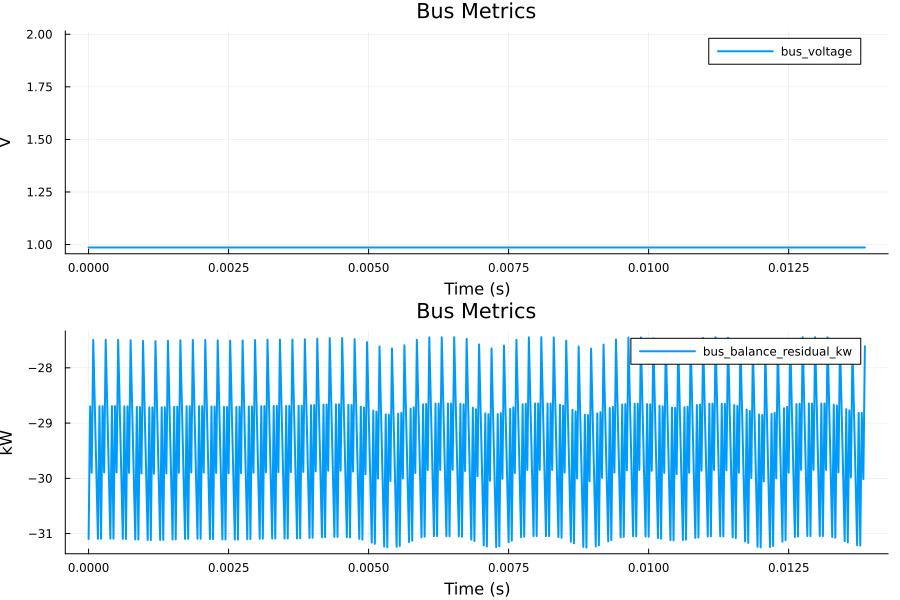

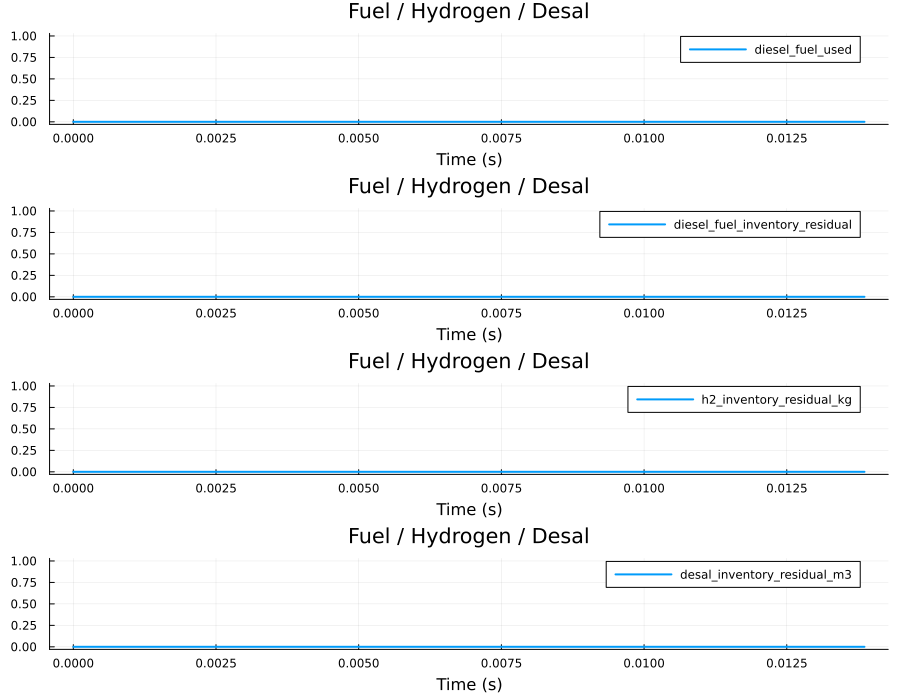

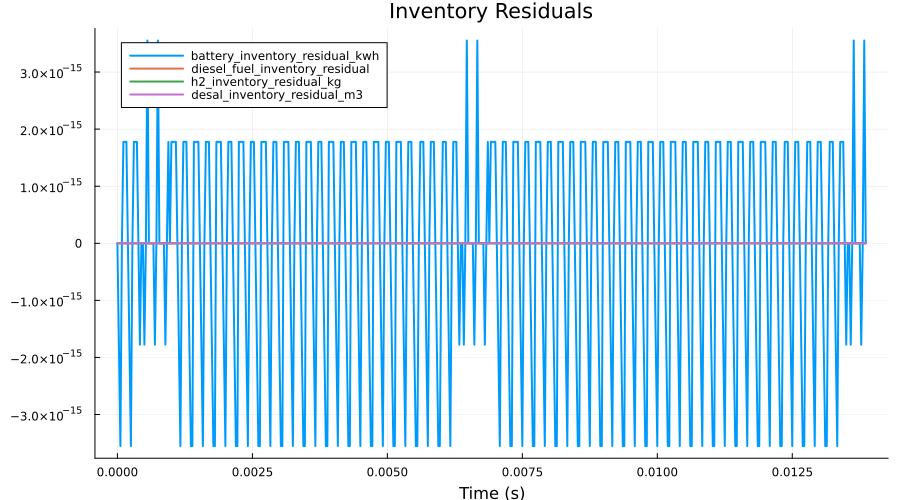

In [46]:

t = [s.time for s in states]  # change if your time field has a different name

outnames = (
    :solar_power_kw, :wind_power_kw, :wave_power_kw, :hydrokinetic_power_kw,
    :diesel_power_kw, :battery_power_kw, :load_power_kw, :h2_power_kw,
    :desal_power_kw, :net_bus_power_kw, :bus_voltage, :diesel_fuel_used,
    :bus_balance_residual_kw, :battery_inventory_residual_kwh,
    :diesel_fuel_inventory_residual, :h2_inventory_residual_kg,
    :desal_inventory_residual_m3
)

getseries(name) = [getfield(o, name) for o in outputs]

# Figure 1: power terms
p1 = plot(title="Power Flows", xlabel="Time (s)", ylabel="kW", size=(900, 500))
for name in (
    :solar_power_kw, :wind_power_kw, :wave_power_kw, :hydrokinetic_power_kw,
    :diesel_power_kw, :battery_power_kw, :load_power_kw, :h2_power_kw,
    :desal_power_kw, :net_bus_power_kw
)
    plot!(p1, t, getseries(name), lw=2, label=String(name))
end
display(p1)

# Figure 2: bus metrics
p2 = plot(title="Bus Metrics", xlabel="Time (s)", size=(900, 600), layout=(2,1))
plot!(p2[1], t, getseries(:bus_voltage), lw=2, label="bus_voltage", ylabel="V")
plot!(p2[2], t, getseries(:bus_balance_residual_kw), lw=2, label="bus_balance_residual_kw", ylabel="kW")
display(p2)

# Figure 3: fuel / usage
p3 = plot(title="Fuel / Hydrogen / Desal", xlabel="Time (s)", size=(900, 700), layout=(4,1))
plot!(p3[1], t, getseries(:diesel_fuel_used), lw=2, label="diesel_fuel_used")
plot!(p3[2], t, getseries(:diesel_fuel_inventory_residual), lw=2, label="diesel_fuel_inventory_residual")
plot!(p3[3], t, getseries(:h2_inventory_residual_kg), lw=2, label="h2_inventory_residual_kg")
plot!(p3[4], t, getseries(:desal_inventory_residual_m3), lw=2, label="desal_inventory_residual_m3")
display(p3)

# Figure 4: storage residuals
p4 = plot(title="Inventory Residuals", xlabel="Time (s)", size=(900, 500))
for name in (
    :battery_inventory_residual_kwh,
    :diesel_fuel_inventory_residual,
    :h2_inventory_residual_kg,
    :desal_inventory_residual_m3
)
    plot!(p4, t, getseries(name), lw=2, label=String(name))
end
display(p4)

In [30]:
# set azimuth
surface_azimuth = 180.0

# optimize installation tilt and azimuth
mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], surface_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

function g!(G, orientation)
    ForwardDiff.gradient!(G, mean_power, orientation)
end

x0 = [10.0]
lower = [0.0]
upper = [90.0]

res = optimize(mean_power, g!, lower, upper, x0, Fminbox(BFGS()))

println("Optimal installation tilt: ", res.minimizer[1])
println("Maximum mean power: ", -res.minimum)

LoadError: BoundsError: attempt to access Float64 at index [2]